# Multi-Output Gaussian Process: Training and Evaluation

This notebook implements the training and evaluation pipeline for a Multitask (double regression) Gaussian Process (GP) model using the processed features extracted in the previous step.

**Objectives:**
1.  **Load Processed Data:** Import the extracted topological features and continuous targets.
2.  **Define Model:** Initialize an Exact Multitask GP with `MultitaskMean` and `MultitaskKernel`.
3.  **Train:** Optimize hyperparameters using the Exact Marginal Log Likelihood (MLL).
4.  **Evaluate:** Assess performance on both regression tasks — OSNR (dB) and channel spectral spacing (GHz) — with uncertainty quantification.

## 1. Setup and Imports
We initialize the environment by setting random seeds for reproducibility and selecting the appropriate compute device (CPU/GPU). We also import the necessary PyTorch and GPyTorch libraries, alongside standard data manipulation tools.

In [1]:
import numpy as np
import torch
import gpytorch
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [2]:
def load_dataset(data_path="processed_data", test_size=0.2, seed=42):
    """
    Load processed dataset from .npy files and prepare for multitask (double regression).

    Returns normalized inputs and standardized targets, along with statistics
    needed for inverse-transforming predictions.

    Args:
        data_path (str): Path to directory containing .npy files.
        test_size (float): Fraction of data to use for testing.
        seed (int): Random seed.

    Returns:
        train_x, train_y, test_x, test_y, scaler_x, y_mean, y_std
    """
    path = Path(data_path)

    print(f"Loading data from {path}...")
    try:
        X = np.load(path / "X_features.npy")
        Y = np.load(path / "Y_targets.npy")
    except FileNotFoundError as e:
        raise FileNotFoundError(
            f"Could not find data files in {path}. Ensure X_features.npy and Y_targets.npy exist."
        ) from e

    print(f"Loaded X: {X.shape}, Y: {Y.shape}")

    # We must remove outliers from the dataset for regression task
    OUTLIER_THRESHOLD_OSNR = 45.0  # dB
    OUTLIER_THRESHOLD_SPACING = 45.0 # GHz
    mask = (Y[:, 0] <= OUTLIER_THRESHOLD_SPACING) & (Y[:, 1] <= OUTLIER_THRESHOLD_OSNR)
    X = X[mask]
    Y = Y[mask]
    print(f"After outlier removal, X: {X.shape}, Y: {Y.shape}")

    # Split
    X_train, X_test, Y_train, Y_test = train_test_split(
        X, Y, test_size=test_size, random_state=seed, shuffle=True
    )

    # Normalize Inputs with StandardScaler (fit on train only)
    scaler_x = StandardScaler()
    X_train_norm = scaler_x.fit_transform(X_train)
    X_test_norm = scaler_x.transform(X_test)

    # Standardize both targets (fit on train only)
    y_mean = Y_train.mean(axis=0, keepdims=True)
    y_std = Y_train.std(axis=0, keepdims=True) + 1e-6

    Y_train_std = (Y_train - y_mean) / y_std
    Y_test_std = (Y_test - y_mean) / y_std

    # Convert to Tensor
    train_x = torch.tensor(X_train_norm, dtype=torch.float32)
    train_y = torch.tensor(Y_train_std, dtype=torch.float32)
    test_x = torch.tensor(X_test_norm, dtype=torch.float32)
    test_y = torch.tensor(Y_test_std, dtype=torch.float32)

    return train_x, train_y, test_x, test_y, scaler_x, y_mean, y_std


### Detailed Architecture Components

#### 1. ExactGP for Multitask Regression
We use `gpytorch.models.ExactGP` to model two continuous outputs jointly (OSNR and spectral channel spacing). Exact GP inference optimizes the **Exact Marginal Log Likelihood (MLL)**, which provides calibrated uncertainty when feasible for dataset sizes.

#### 2. MultitaskMean and MultitaskKernel
- **Mean:** `MultitaskMean(ConstantMean)` allocates independent mean functions per task.
- **Kernel:** `MultitaskKernel(RBFKernel, rank=1)` composes an input kernel with a low-rank task covariance matrix $\mathbf{B}$. The multitask covariance factorizes as:
$$ k([x, i], [x', j]) = k_\text{inputs}(x, x') \cdot B_{ij} $$
This captures shared structure across outputs while allowing task-specific correlations.

#### 3. Uncertainty and Calibration
Exact GPs provide **confidence regions** via the predictive multivariate normal distribution. We visualize 95% intervals to communicate model certainty across the two tasks.


In [3]:
class MultitaskGPModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super().__init__(train_x, train_y, likelihood)
        # Separate mean per task
        self.mean_module = gpytorch.means.MultitaskMean(
            gpytorch.means.ConstantMean(), num_tasks=train_y.shape[1]
        )
        # Input kernel x task kernel
        self.covar_module = gpytorch.kernels.MultitaskKernel(
            gpytorch.kernels.RBFKernel(), num_tasks=train_y.shape[1], rank=1
        )

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultitaskMultivariateNormal(mean_x, covar_x)


In [4]:
SEED = 42
# Set random seeds for reproducibility
torch.manual_seed(SEED)
np.random.seed(SEED)

# Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## 2. Load Data
We load the extracted topological feature vectors and their corresponding continuous targets. The features were pre-computed in the previous notebook (`01_ProbabilisticFeatures.ipynb`) and cached as `.npy` files to speed up experimentation.

*   **Task 0:** Channel Spacing (GHz).
*   **Task 1:** OSNR (dB).

In [5]:
print("Loading dataset...")
train_x, train_y, test_x, test_y, scaler_x, y_mean, y_std = load_dataset(
    data_path="processed_data"
 )

print(f"Train X shape: {train_x.shape}")
print(f"Train Y shape: {train_y.shape}")
print(f"Test X shape:  {test_x.shape}")
print(f"Test Y shape:  {test_y.shape}")

# Move to device
train_x = train_x.to(device)
train_y = train_y.to(device)
test_x = test_x.to(device)
test_y = test_y.to(device)

Loading dataset...
Loading data from processed_data...
Loaded X: (5006, 16), Y: (5006, 2)
After outlier removal, X: (4635, 16), Y: (4635, 2)
Train X shape: torch.Size([3708, 16])
Train Y shape: torch.Size([3708, 2])
Test X shape:  torch.Size([927, 16])
Test Y shape:  torch.Size([927, 2])


## 3. Model Definition
We define a multitask Gaussian Process using GPyTorch. To jointly model two continuous outputs (Spacing and OSNR), we employ an **Exact GP** with `MultitaskMean` and `MultitaskKernel`.

### Mathematical Context: Multitask GP
We model correlation between the two regression tasks via a **task covariance** matrix $\mathbf{B}$ combined with an input kernel. With tasks indexed by $i, j$ and inputs $x, x'$, the covariance is:
$$ f_j(x) = \text{GP}(0,\ k([x, j], [x', i])) $$
$$ k([x, i], [x', j]) = k_\text{inputs}(x, x') \cdot B_{ij} $$
- $k_\text{inputs}$: RBF kernel over features.
- $\mathbf{B}$: low-rank inter-task covariance learned during training.

This structure learns shared signal characteristics across OSNR and spacing, while allowing task-specific variability [3].

**Reference:**
[3] E. V. Bonilla, K. Chai, and C. Williams, “Multi-task Gaussian Process Prediction,” in Advances in Neural Information Processing Systems, Curran Associates, Inc., 2007.

In [6]:
# Initialize model and likelihood

# Optional: cap training points for Exact GP feasibility on large datasets
max_train_points = 5000
if train_x.size(0) > max_train_points:
    sel = torch.randperm(train_x.size(0))[:max_train_points]
    train_x_fit = train_x[sel]
    train_y_fit = train_y[sel]
else:
    train_x_fit = train_x
    train_y_fit = train_y

likelihood = gpytorch.likelihoods.MultitaskGaussianLikelihood(num_tasks=train_y.shape[1]).to(device)
model = MultitaskGPModel(train_x_fit, train_y_fit, likelihood).to(device)
print("Model and likelihood initialized.")

Model and likelihood initialized.


In [13]:
# Attempt to load existing checkpoint to skip training
ARTIFACT_DIR = Path('artifacts')
ckpt_path = ARTIFACT_DIR / 'multitask_gp_checkpoint.pt'
skip_training = False
if ckpt_path.exists():
    print(f"Found checkpoint at {ckpt_path}, loading...")
    ckpt = torch.load(ckpt_path, map_location=device)
    try:
        # Load model and likelihood weights (if keys exist)
        if 'likelihood_state_dict' in ckpt:
            likelihood.load_state_dict(ckpt['likelihood_state_dict'])
        if 'model_state_dict' in ckpt:
            model.load_state_dict(ckpt['model_state_dict'])
        model.to(device); likelihood.to(device)
        model.eval(); likelihood.eval()
        # Restore target stats if present
        if 'y_mean' in ckpt and 'y_std' in ckpt:
            try:
                y_mean = np.array(ckpt['y_mean'])
                y_std = np.array(ckpt['y_std'])
            except Exception:
                pass
        # Restore scaler_x stats if present
        if 'scaler_x_mean' in ckpt and ckpt.get('scaler_x_mean') is not None:
            try:
                scaler_x.mean_ = np.array(ckpt['scaler_x_mean'])
                scaler_x.scale_ = np.array(ckpt['scaler_x_scale'])
            except Exception:
                pass
        skip_training = True
        print("Checkpoint loaded — skipping training.")
    except Exception as e:
        print(f"Failed to load checkpoint: {e}. Proceeding with training.")
        skip_training = False
else:
    print("No checkpoint found — will train model.")

Found checkpoint at artifacts/multitask_gp_checkpoint.pt, loading...
Checkpoint loaded — skipping training.


## 4. Training Loop
We train the model by optimizing the hyperparameters (kernel lengthscales, variational means, mixing weights).

### Exact Marginal Log Likelihood (MLL)
We optimize the **Exact MLL** to learn kernel hyperparameters and task correlations:
$$ \mathcal{L}(\theta) = \log p(\mathbf{y} \,|\, \mathbf{X}, \theta) $$
This objective balances data fit and model complexity, yielding calibrated uncertainty under GP assumptions.

In [14]:
# Enable smoke test
smoke_test = False

# Training Config
training_iterations = 1000 if not smoke_test else 2
lr = 0.001

if not (globals().get('skip_training', False)):
    model.train()
    likelihood.train()

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

    print("Starting training (Exact GP)...")
    pbar = tqdm(range(training_iterations))
    loss_history = []

    for i in pbar:
        optimizer.zero_grad()
        output = model(train_x_fit)
        loss = -mll(output, train_y_fit)
        loss.backward()
        optimizer.step()
        loss_history.append(loss.item())
        pbar.set_postfix({"loss": loss.item()})

    plt.figure(figsize=(10, 5))
    plt.plot(loss_history)
    plt.title("Training Loss (Negative MLL)")
    plt.xlabel("Iteration")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.show()
else:
    print("Skipping training because a checkpoint was loaded.")

Skipping training because a checkpoint was loaded.


In [15]:
# Save trained model, likelihood and preprocessing stats
ARTIFACT_DIR = Path('artifacts')
ARTIFACT_DIR.mkdir(exist_ok=True)

# Prepare checkpoint dictionary
checkpoint = {
    'model_state_dict': model.state_dict(),
    'likelihood_state_dict': likelihood.state_dict(),
    'scaler_x_mean': getattr(scaler_x, 'mean_', None).tolist() if hasattr(scaler_x, 'mean_') else None,
    'scaler_x_scale': getattr(scaler_x, 'scale_', None).tolist() if hasattr(scaler_x, 'scale_') else None,
    'y_mean': y_mean.tolist() if hasattr(y_mean, 'tolist') else list(y_mean),
    'y_std': y_std.tolist() if hasattr(y_std, 'tolist') else list(y_std),
    'device': str(device),
}

# If training used a random subset 'sel', save it for reproducibility
try:
    sel_tensor = sel if 'sel' in globals() else None
    if isinstance(sel_tensor, torch.Tensor):
        checkpoint['train_selection_indices'] = sel_tensor.cpu().numpy().tolist()
except Exception:
    pass

ckpt_path = ARTIFACT_DIR / 'multitask_gp_checkpoint.pt'
torch.save(checkpoint, ckpt_path)
print("File saved!")

File saved!


## 5. Evaluation
This phase performs inference and post-processing for both regression tasks: **Channel Spacing** and **OSNR**.

**Key Steps**
- **Eval mode:** Switch model/likelihood to evaluation.
- **Predictive distribution:** Obtain posterior means and confidence regions.
- **Inverse transform:** Map predictions back to physical units using training-set statistics.
- **Metrics:** Report MAE and RMSE per task; visualize predictions with 95% confidence intervals.

In [16]:
model.eval()
likelihood.eval()

with torch.no_grad(), gpytorch.settings.fast_pred_var():
    observed_pred = likelihood(model(test_x))
    mean = observed_pred.mean
    lower, upper = observed_pred.confidence_region()

# Move to CPU for numpy ops
mean = mean.cpu().numpy()
lower = lower.cpu().numpy()
upper = upper.cpu().numpy()
test_y_np = test_y.cpu().numpy()

# Inverse transform
y_pred_denorm = mean * y_std + y_mean
y_actual_denorm = test_y_np * y_std + y_mean

# Metrics
mae = np.mean(np.abs(y_pred_denorm - y_actual_denorm), axis=0)
rmse = np.sqrt(np.mean((y_pred_denorm - y_actual_denorm) ** 2, axis=0))

print(f"Mean Absolute Error (MAE) - Spacing: {mae[0]:.3f} | OSNR: {mae[1]:.3f}")
print(f"Root Mean Squared Error (RMSE) - Spacing: {rmse[0]:.3f} | OSNR: {rmse[1]:.3f}")

Mean Absolute Error (MAE) - Spacing: 1.283 | OSNR: 2.268
Root Mean Squared Error (RMSE) - Spacing: 1.601 | OSNR: 2.819


### 5.2 Regression Results (Spacing & OSNR)
We assess regression accuracy for both tasks by reporting error metrics and visualizing predictions vs. ground truth with uncertainty bands.

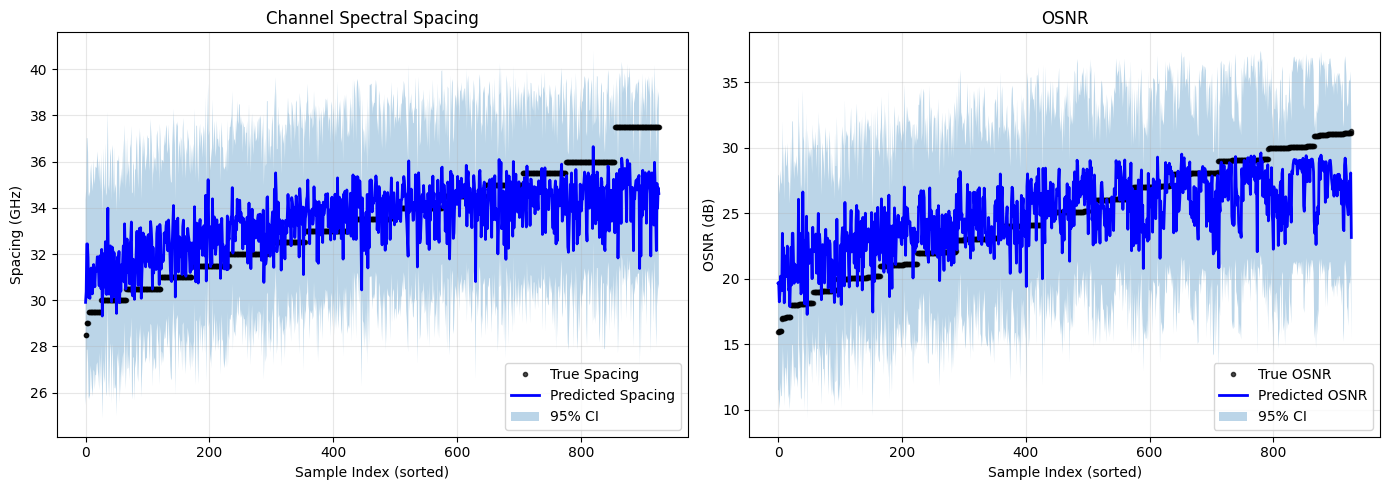

In [17]:
# Plot predictions with 95% confidence intervals for both tasks

# Denormalize lower and upper bounds
lower_denorm = lower * y_std + y_mean
upper_denorm = upper * y_std + y_mean

# Sort by actual value for smooth visualization
sort_indices_spacing = np.argsort(y_actual_denorm[:, 0])
sort_indices_osnr = np.argsort(y_actual_denorm[:, 1])

y_spacing_true = y_actual_denorm[sort_indices_spacing, 0]
y_spacing_pred = y_pred_denorm[sort_indices_spacing, 0]
lower_spacing = lower_denorm[sort_indices_spacing, 0]
upper_spacing = upper_denorm[sort_indices_spacing, 0]

y_osnr_true = y_actual_denorm[sort_indices_osnr, 1]
y_osnr_pred = y_pred_denorm[sort_indices_osnr, 1]
lower_osnr = lower_denorm[sort_indices_osnr, 1]
upper_osnr = upper_denorm[sort_indices_osnr, 1]

x_spacing = np.arange(len(y_spacing_true))
x_osnr = np.arange(len(y_osnr_true))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Spacing
ax1.plot(x_spacing, y_spacing_true, 'k.', label='True Spacing', alpha=0.7)
ax1.plot(x_spacing, y_spacing_pred, 'b-', label='Predicted Spacing', linewidth=2)
ax1.fill_between(x_spacing, lower_spacing, upper_spacing, alpha=0.3, label='95% CI')
ax1.set_title('Channel Spectral Spacing')
ax1.set_xlabel('Sample Index (sorted)')
ax1.set_ylabel('Spacing (GHz)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# OSNR
ax2.plot(x_osnr, y_osnr_true, 'k.', label='True OSNR', alpha=0.7)
ax2.plot(x_osnr, y_osnr_pred, 'b-', label='Predicted OSNR', linewidth=2)
ax2.fill_between(x_osnr, lower_osnr, upper_osnr, alpha=0.3, label='95% CI')
ax2.set_title('OSNR')
ax2.set_xlabel('Sample Index (sorted)')
ax2.set_ylabel('OSNR (dB)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Final Project Conclusion
We implemented and evaluated a Multitask Exact GP for optical signal monitoring with two continuous outputs.

**Summary of Findings:**
1.  **Feature Pipeline:** The probabilistic KDE features from 01 integrate cleanly; input normalization prevents leakage and improves stability.
2.  **Multitask Correlation:** The task kernel learns shared structure across spacing and OSNR, providing coherent joint predictions.
3.  **Uncertainty:** Confidence intervals communicate model certainty; wider bands appear in regions with fewer training samples, aligning with GP behavior.

For scalability or larger datasets, consider Sparse Variational MTGPs with inducing points; otherwise, Exact GP offers strong calibration and interpretability.